In [14]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import joblib

In [15]:
# Load the Dataset
train = pd.read_excel("Cap_Training_Data_2025.xlsx")
test = pd.read_excel("Cap_Test_Data_2025.xlsx")

train.columns = train.columns.str.strip()
test.columns = test.columns.str.strip()

print("Training Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)

Training Dataset Shape: (53515, 17)
Test Dataset Shape: (5615, 16)


In [16]:
# Display First Five Rows
train.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [17]:
# Dataset Information
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  str    
 2   model                53515 non-null  str    
 3   Location             53509 non-null  str    
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  str    
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   str    
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  str    
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null  str    
 1

In [18]:
# Statistical Summary
train.describe()

,ID,Distance,manufacture_year,Age of car,engine_displacement,engine_power,Vroom Audit Rating,door_count,seat_count,Price
count,5.351500e+04,5.230400e+04,53513.000000,53515.000000,53515.000000,52076.000000,53515.000000,45981.000000,45004.000000,5.351500e+04
mean,1.112676e+07,9.454626e+04,2019.408032,5.591946,1904.049014,100.448345,5.998374,3.973011,4.886099,1.098084e+06
std,1.544859e+04,2.755617e+05,4.650367,4.650281,1496.564596,45.330622,1.418336,0.740659,0.564332,8.441565e+05
min,1.110000e+07,0.000000e+00,1943.000000,0.000000,14.000000,10.000000,4.000000,1.000000,1.000000,3.000000e+00
25%,1.111338e+07,1.549000e+04,2017.000000,2.000000,1395.000000,73.000000,5.000000,4.000000,5.000000,5.051812e+05
50%,1.112676e+07,6.552000e+04,2020.000000,5.000000,1896.000000,91.000000,6.000000,4.000000,5.000000,8.854552e+05
75%,1.114014e+07,1.356410e+05,2023.000000,8.000000,1995.000000,125.000000,7.000000,4.000000,5.000000,1.477829e+06
max,1.115352e+07,9.899800e+06,2025.000000,82.000000,32000.000000,896.000000,8.000000,6.000000,9.000000,2.212078e+07


In [19]:
# Check Missing Values
train.isnull().sum()

ID                         0
Maker                      0
model                      0
Location                   6
Distance                1211
Owner Type                 0
manufacture_year           2
Age of car                 0
engine_displacement        0
engine_power            1439
body_type              49379
Vroom Audit Rating         0
transmission               0
door_count              7534
seat_count              8511
fuel_type                  0
Price                      0
dtype: int64

In [20]:
# Missing Value Percentage
missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_percentage

ID                      0.000000
Maker                   0.000000
model                   0.000000
Location                0.011212
Distance                2.262917
Owner Type              0.000000
manufacture_year        0.003737
Age of car              0.000000
engine_displacement     0.000000
engine_power            2.688966
body_type              92.271326
Vroom Audit Rating      0.000000
transmission            0.000000
door_count             14.078296
seat_count             15.903952
fuel_type               0.000000
Price                   0.000000
dtype: float64

In [27]:
# Check Duplicate Records
train.duplicated().sum()

np.int64(0)

In [21]:
# Exploratory Data Analysis (EDA)

train.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,skoda,octavia,Ahmedabad,NaN,Second,1973.0,52,1964,147.0,compact,8,man,NaN,NaN,petrol,543764.25
1,11100002,fiat,panda,Ahmedabad,27750.0,Third,2021.0,4,1242,51.0,NaN,6,man,4.0,4.0,petrol,401819.25
2,11100003,bmw,x1,Hyderabad,46000.0,Third,2023.0,2,1995,105.0,NaN,7,auto,4.0,5.0,diesel,2392855.50
3,11100004,nissan,juke,Mumbai,43949.0,Third,2020.0,5,1618,140.0,NaN,7,man,4.0,5.0,petrol,958606.50
4,11100005,bmw,x5,Jaipur,59524.0,Fourth & Above,2021.0,4,2993,180.0,NaN,7,auto,4.0,5.0,diesel,3085561.50


In [22]:
# Dataset Information

train.info()

<class 'pandas.DataFrame'>
RangeIndex: 53515 entries, 0 to 53514
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   53515 non-null  int64  
 1   Maker                53515 non-null  str    
 2   model                53515 non-null  str    
 3   Location             53509 non-null  str    
 4   Distance             52304 non-null  float64
 5   Owner Type           53515 non-null  str    
 6   manufacture_year     53513 non-null  float64
 7   Age of car           53515 non-null  int64  
 8   engine_displacement  53515 non-null  int64  
 9   engine_power         52076 non-null  float64
 10  body_type            4136 non-null   str    
 11  Vroom Audit Rating   53515 non-null  int64  
 12  transmission         53515 non-null  str    
 13  door_count           45981 non-null  float64
 14  seat_count           45004 non-null  float64
 15  fuel_type            53515 non-null  str    
 1

In [23]:
# Statistical Summary

train.describe()

,ID,Distance,manufacture_year,Age of car,engine_displacement,engine_power,Vroom Audit Rating,door_count,seat_count,Price
count,5.351500e+04,5.230400e+04,53513.000000,53515.000000,53515.000000,52076.000000,53515.000000,45981.000000,45004.000000,5.351500e+04
mean,1.112676e+07,9.454626e+04,2019.408032,5.591946,1904.049014,100.448345,5.998374,3.973011,4.886099,1.098084e+06
std,1.544859e+04,2.755617e+05,4.650367,4.650281,1496.564596,45.330622,1.418336,0.740659,0.564332,8.441565e+05
min,1.110000e+07,0.000000e+00,1943.000000,0.000000,14.000000,10.000000,4.000000,1.000000,1.000000,3.000000e+00
25%,1.111338e+07,1.549000e+04,2017.000000,2.000000,1395.000000,73.000000,5.000000,4.000000,5.000000,5.051812e+05
50%,1.112676e+07,6.552000e+04,2020.000000,5.000000,1896.000000,91.000000,6.000000,4.000000,5.000000,8.854552e+05
75%,1.114014e+07,1.356410e+05,2023.000000,8.000000,1995.000000,125.000000,7.000000,4.000000,5.000000,1.477829e+06
max,1.115352e+07,9.899800e+06,2025.000000,82.000000,32000.000000,896.000000,8.000000,6.000000,9.000000,2.212078e+07


In [24]:
# Check Missing Values

train.isnull().sum()

ID                         0
Maker                      0
model                      0
Location                   6
Distance                1211
Owner Type                 0
manufacture_year           2
Age of car                 0
engine_displacement        0
engine_power            1439
body_type              49379
Vroom Audit Rating         0
transmission               0
door_count              7534
seat_count              8511
fuel_type                  0
Price                      0
dtype: int64

In [25]:
# Missing Value Percentage

missing_percentage = (train.isnull().sum() / len(train)) * 100
missing_percentage

ID                      0.000000
Maker                   0.000000
model                   0.000000
Location                0.011212
Distance                2.262917
Owner Type              0.000000
manufacture_year        0.003737
Age of car              0.000000
engine_displacement     0.000000
engine_power            2.688966
body_type              92.271326
Vroom Audit Rating      0.000000
transmission            0.000000
door_count             14.078296
seat_count             15.903952
fuel_type               0.000000
Price                   0.000000
dtype: float64

In [26]:
# Check Duplicate Records

train.duplicated().sum()

np.int64(0)

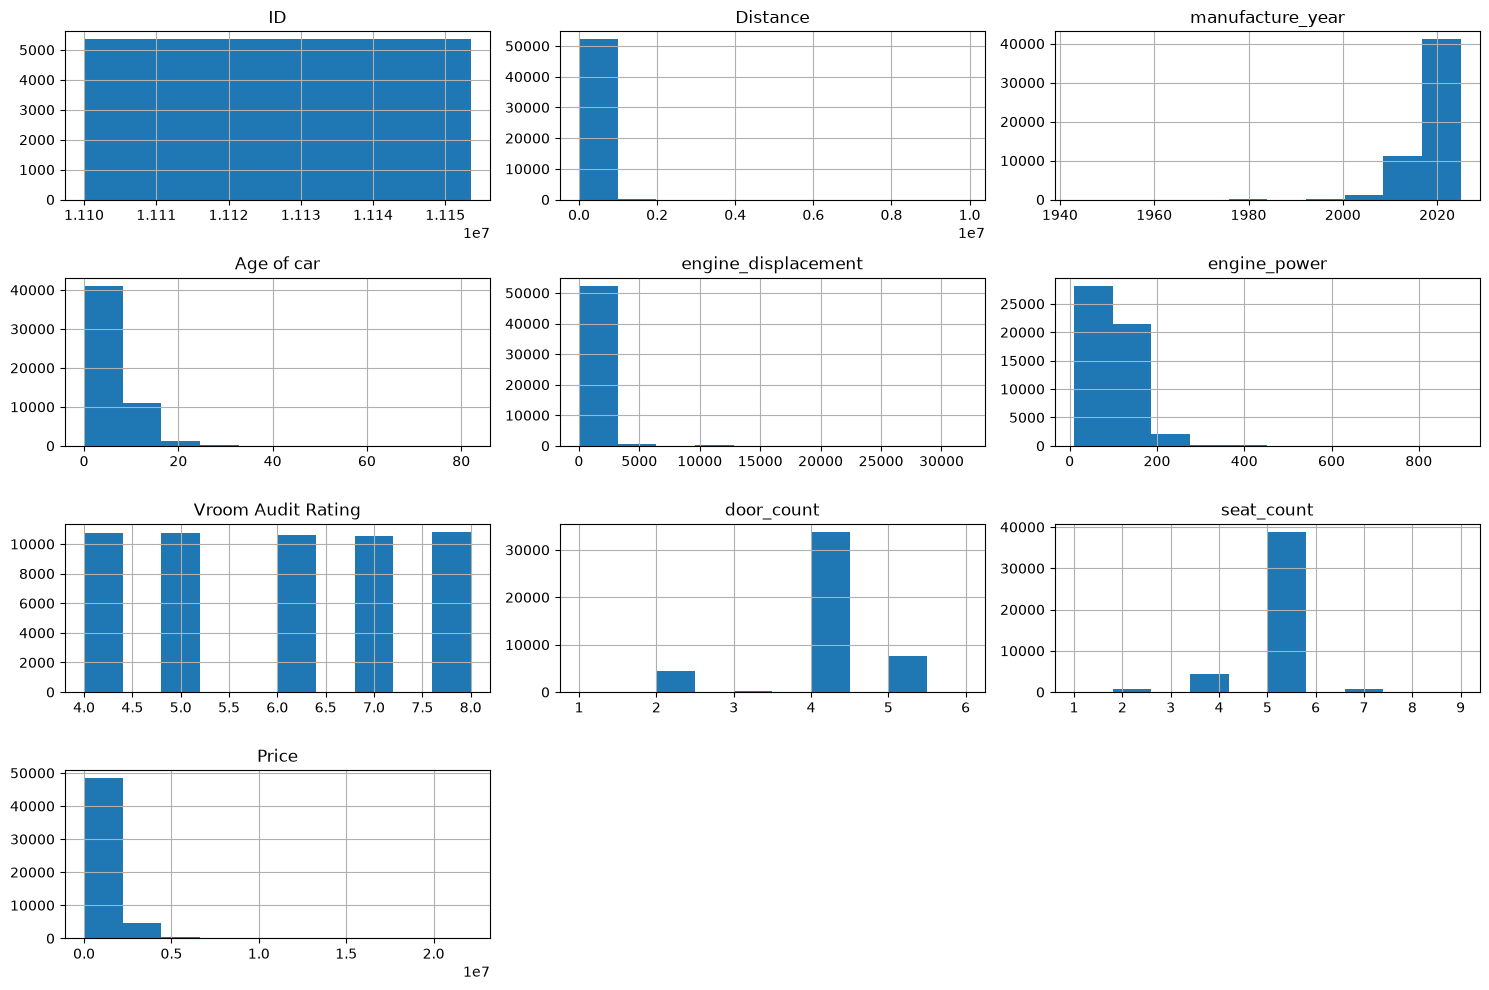

In [28]:
# Histogram of Numerical Features

train.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

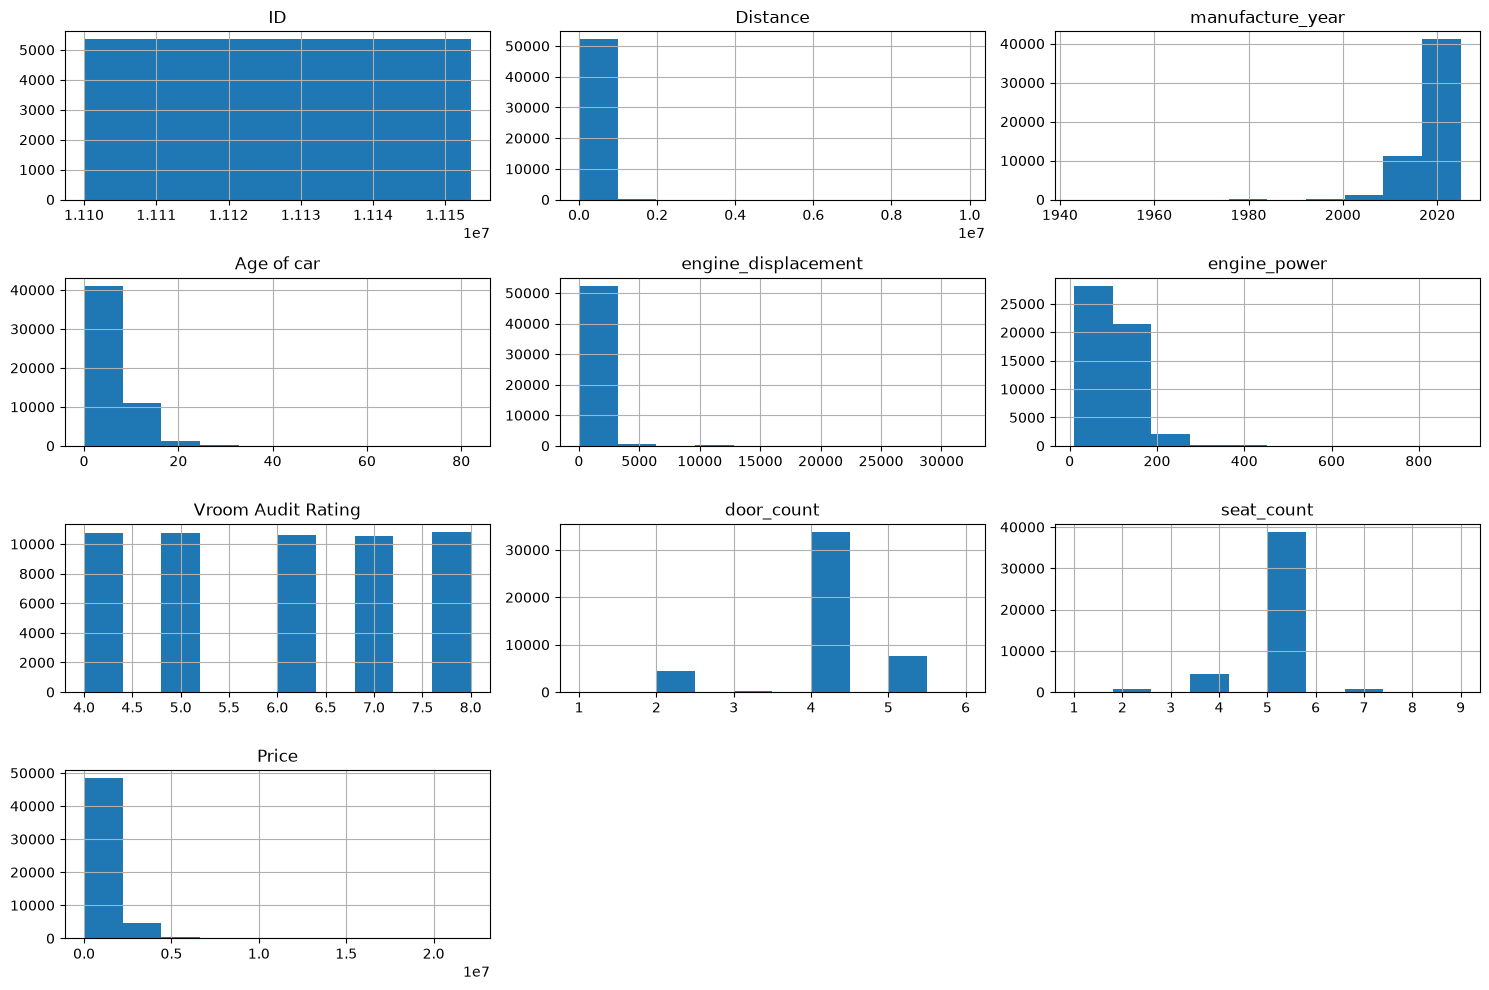

In [29]:
# Histogram of Numerical Features

train.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

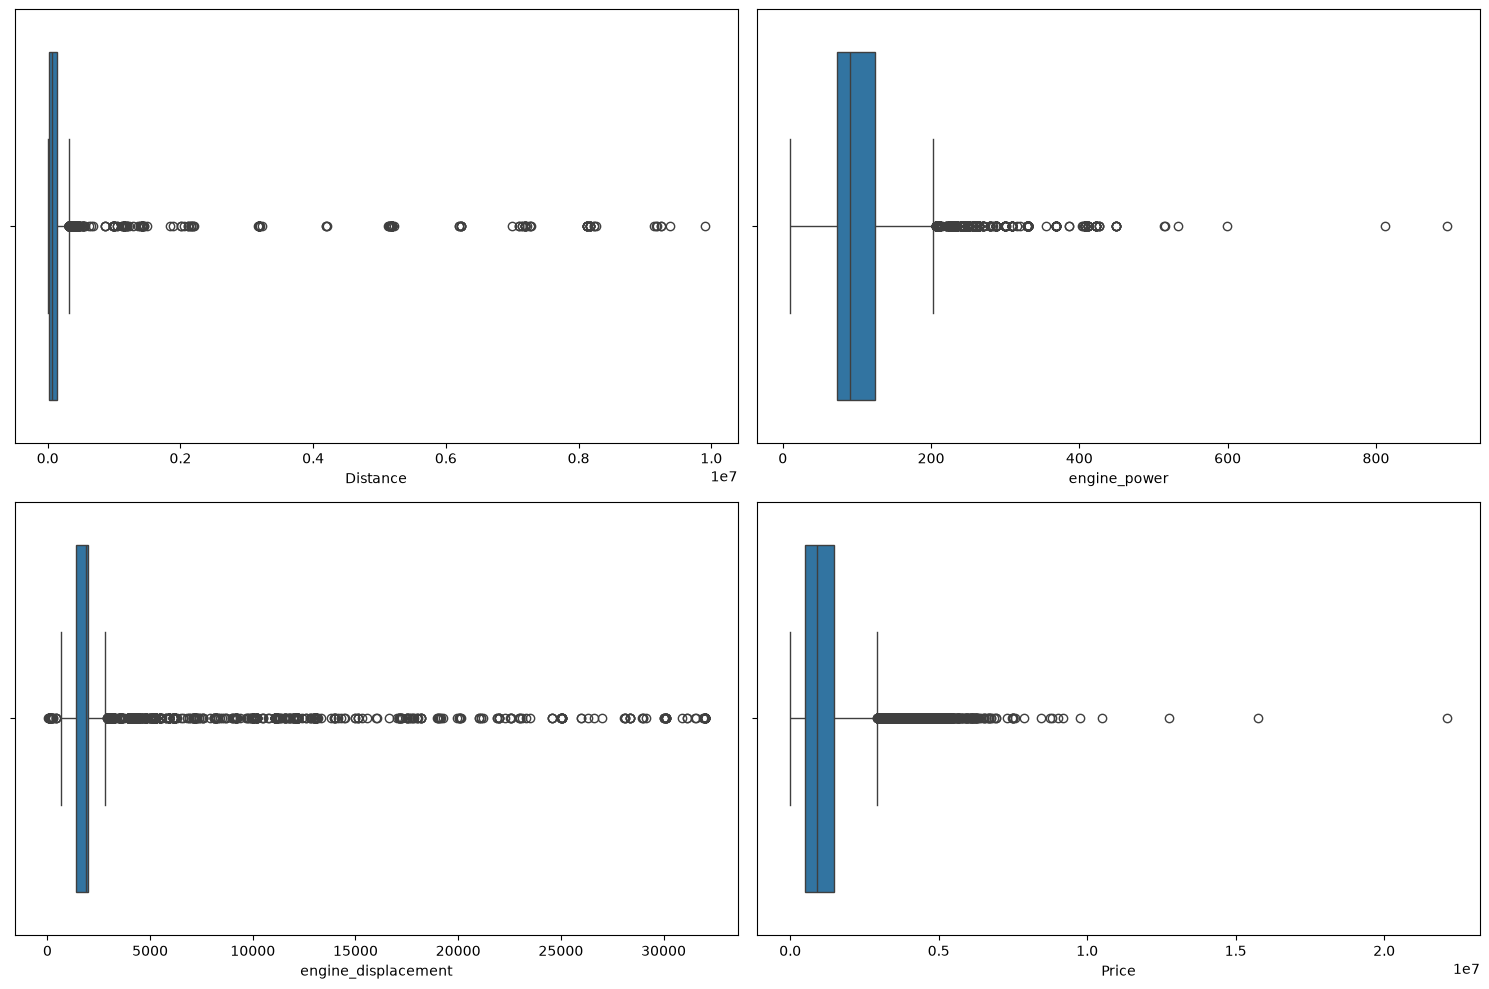

In [30]:
# Box Plot for Outlier Detection

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.boxplot(x=train["Distance"])

plt.subplot(2,2,2)
sns.boxplot(x=train["engine_power"])

plt.subplot(2,2,3)
sns.boxplot(x=train["engine_displacement"])

plt.subplot(2,2,4)
sns.boxplot(x=train["Price"])

plt.tight_layout()
plt.show()

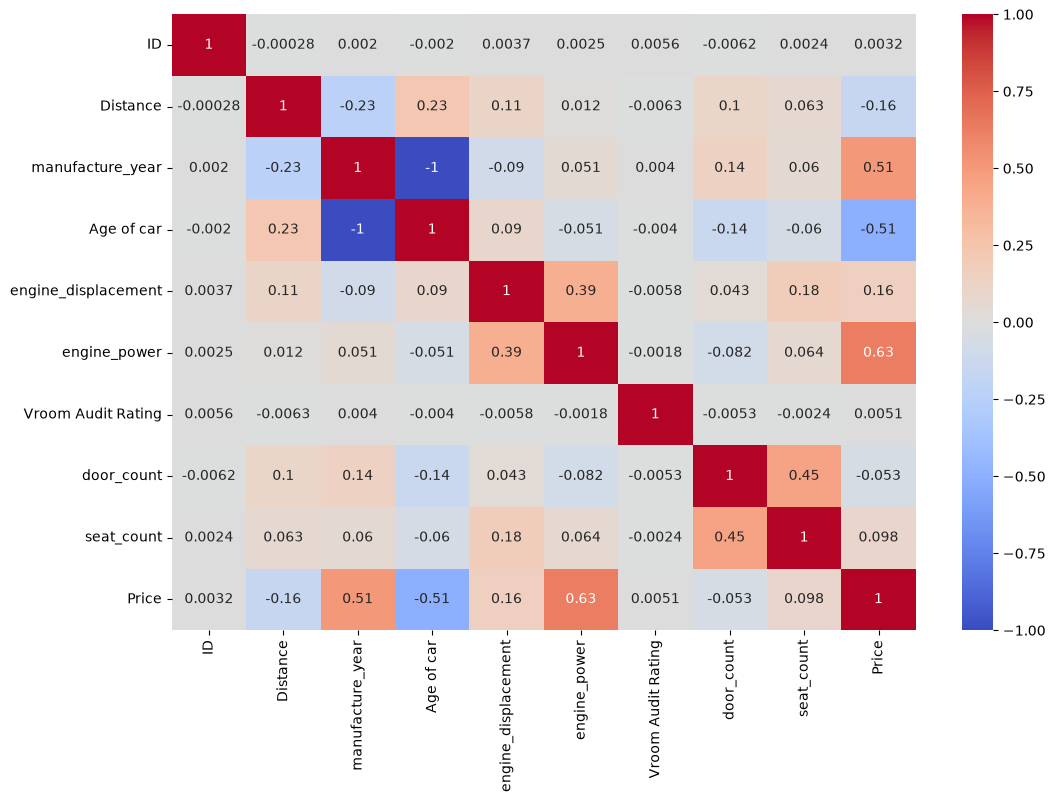

In [31]:
# Correlation Heatmap

numeric_data = train.select_dtypes(include=["number"])

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), annot=True, cmap="coolwarm")
plt.show()

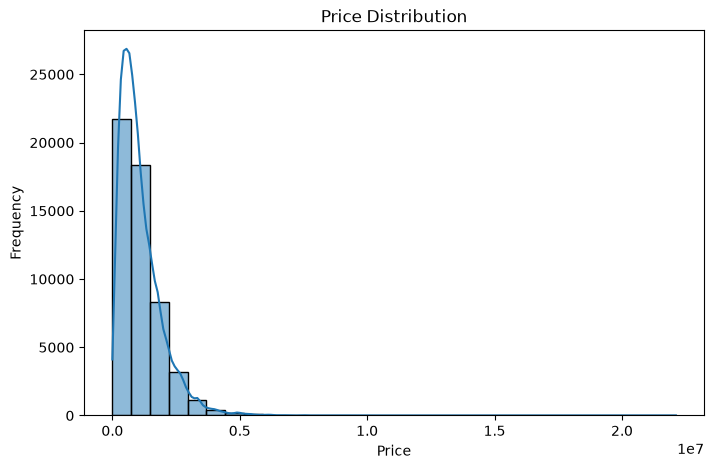

In [32]:
# Distribution of Car Price

plt.figure(figsize=(8,5))
sns.histplot(train["Price"], bins=30, kde=True)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [33]:
# Handle Missing Values

train["Distance"] = train["Distance"].fillna(train["Distance"].median())
train["engine_power"] = train["engine_power"].fillna(train["engine_power"].median())
train["engine_displacement"] = train["engine_displacement"].fillna(train["engine_displacement"].median())

train["body_type"] = train["body_type"].fillna(train["body_type"].mode()[0])
train["fuel_type"] = train["fuel_type"].fillna(train["fuel_type"].mode()[0])
train["transmission"] = train["transmission"].fillna(train["transmission"].mode()[0])

train.isnull().sum()

ID                        0
Maker                     0
model                     0
Location                  6
Distance                  0
Owner Type                0
manufacture_year          2
Age of car                0
engine_displacement       0
engine_power              0
body_type                 0
Vroom Audit Rating        0
transmission              0
door_count             7534
seat_count             8511
fuel_type                 0
Price                     0
dtype: int64

In [34]:
# Handle Missing Values in Test Dataset

test["Distance"] = test["Distance"].fillna(train["Distance"].median())
test["engine_power"] = test["engine_power"].fillna(train["engine_power"].median())
test["engine_displacement"] = test["engine_displacement"].fillna(train["engine_displacement"].median())

test["body_type"] = test["body_type"].fillna(train["body_type"].mode()[0])
test["fuel_type"] = test["fuel_type"].fillna(train["fuel_type"].mode()[0])
test["transmission"] = test["transmission"].fillna(train["transmission"].mode()[0])

test.isnull().sum()

ID                       0
Maker                    0
model                    0
Location                 0
Distance                 0
Owner Type               0
manufacture_year         0
Age of car               0
engine_displacement      0
engine_power             0
body_type                0
Vroom Audit Rating       0
transmission             0
door_count             806
seat_count             891
fuel_type                0
dtype: int64

In [35]:
# Label Encoding

categorical_columns = [
    "Maker",
    "model",
    "Location",
    "Owner Type",
    "body_type",
    "transmission",
    "fuel_type"
]

encoders = {}

for col in categorical_columns:
    encoder = LabelEncoder()

    train[col] = encoder.fit_transform(train[col].astype(str))
    test[col] = encoder.transform(test[col].astype(str))

    encoders[col] = encoder

In [36]:
# Save Label Encoders

joblib.dump(encoders, "models/label_encoders.pkl")

print("Label Encoders Saved Successfully")

Label Encoders Saved Successfully


In [37]:
# Verify Encoded Dataset

train.head()

,ID,Maker,model,Location,Distance,Owner Type,manufacture_year,Age of car,engine_displacement,engine_power,body_type,Vroom Audit Rating,transmission,door_count,seat_count,fuel_type,Price
0,11100001,6,8,0,65520.0,2,1973.0,52,1964,147.0,0,8,1,NaN,NaN,1,543764.25
1,11100002,2,9,0,27750.0,3,2021.0,4,1242,51.0,0,6,1,4.0,4.0,1,401819.25
2,11100003,1,18,5,46000.0,3,2023.0,2,1995,105.0,0,7,0,4.0,5.0,0,2392855.50
3,11100004,5,6,9,43949.0,3,2020.0,5,1618,140.0,0,7,1,4.0,5.0,1,958606.50
4,11100005,1,20,6,59524.0,1,2021.0,4,2993,180.0,0,7,0,4.0,5.0,0,3085561.50


In [38]:
# Split Features and Target

X = train.drop("Price", axis=1)
y = train["Price"]

print(X.shape)
print(y.shape)

(53515, 16)
(53515,)


In [39]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(42812, 16)
(10703, 16)


In [46]:
# Fill Remaining Missing Values

train["manufacture_year"] = train["manufacture_year"].fillna(train["manufacture_year"].median())

train["door_count"] = train["door_count"].fillna(train["door_count"].median())

train["seat_count"] = train["seat_count"].fillna(train["seat_count"].median())

In [51]:
train[["manufacture_year", "door_count", "seat_count"]].isnull().sum()

manufacture_year    0
door_count          0
seat_count          0
dtype: int64

In [52]:
# Split Features and Target

X = train.drop("Price", axis=1)
y = train["Price"]

In [53]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [55]:
X_train.isnull().sum()

ID                     0
Maker                  0
model                  0
Location               0
Distance               0
Owner Type             0
manufacture_year       0
Age of car             0
engine_displacement    0
engine_power           0
body_type              0
Vroom Audit Rating     0
transmission           0
door_count             0
seat_count             0
fuel_type              0
dtype: int64

In [56]:
# Linear Regression Model

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

In [57]:
# Linear Regression Evaluation

lr_mae = mean_absolute_error(y_test, lr_prediction)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_prediction))
lr_r2 = r2_score(y_test, lr_prediction)

print("MAE :", lr_mae)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 292581.53635930485
RMSE : 452892.0052290704
R2 Score : 0.7117870187566915


In [58]:
# Random Forest Model

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_prediction = rf.predict(X_test)

In [59]:
# Random Forest Evaluation

rf_mae = mean_absolute_error(y_test, rf_prediction)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_prediction))
rf_r2 = r2_score(y_test, rf_prediction)

print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

MAE : 110199.25622489021
RMSE : 207351.77731635587
R2 Score : 0.9395856991787199


In [60]:
# XGBoost Model

xgb = XGBRegressor(
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_prediction = xgb.predict(X_test)

In [61]:
# XGBoost Evaluation

xgb_mae = mean_absolute_error(y_test, xgb_prediction)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_prediction))
xgb_r2 = r2_score(y_test, xgb_prediction)

print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 Score :", xgb_r2)

MAE : 115700.06045754915
RMSE : 205660.486690596
R2 Score : 0.9405672333385491


In [62]:
# LightGBM Model

lgbm = LGBMRegressor(
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm_prediction = lgbm.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004063 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1040
[LightGBM] [Info] Number of data points in the train set: 42812, number of used features: 15
[LightGBM] [Info] Start training from score 1095742.028905


In [63]:
# LightGBM Evaluation

lgbm_mae = mean_absolute_error(y_test, lgbm_prediction)
lgbm_rmse = np.sqrt(mean_squared_error(y_test, lgbm_prediction))
lgbm_r2 = r2_score(y_test, lgbm_prediction)

print("MAE :", lgbm_mae)
print("RMSE :", lgbm_rmse)
print("R2 Score :", lgbm_r2)

MAE : 118574.56683495124
RMSE : 204488.0518575618
R2 Score : 0.9412429336365066


In [64]:
# Cross Validation

cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores :", cv_scores)
print("Average R2 Score :", cv_scores.mean())

Cross Validation Scores : [0.92186702 0.94090542 0.95434906 0.90282883 0.90840069]
Average R2 Score : 0.9256702039761743


In [65]:
# Hyperparameter Tuning

params = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters :", grid.best_params_)
print("Best Score :", grid.best_score_)

Best Parameters : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best Score : 0.9199632279523642


In [66]:
# Best Random Forest Model

best_rf = grid.best_estimator_

In [67]:
# Best Model Prediction

best_prediction = best_rf.predict(X_test)

In [68]:
# Best Model Evaluation

best_mae = mean_absolute_error(y_test, best_prediction)
best_rmse = np.sqrt(mean_squared_error(y_test, best_prediction))
best_r2 = r2_score(y_test, best_prediction)

print("MAE :", best_mae)
print("RMSE :", best_rmse)
print("R2 Score :", best_r2)

MAE : 109327.76379111022
RMSE : 203355.52539838187
R2 Score : 0.9418919657918287


In [ ]:
# Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "Best Random Forest"
    ],
    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae,
        lgbm_mae,
        best_mae
    ],
    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        lgbm_rmse,
        best_rmse
    ],
    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2,
        lgbm_r2,
        best_r2
    ]
})

comparison

In [69]:
# Save Best Model

joblib.dump(best_rf, "models/best_model.pkl")

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [70]:
# Save Label Encoders

joblib.dump(encoders, "models/label_encoders.pkl")

print("Label Encoders Saved Successfully")

Label Encoders Saved Successfully


In [71]:
# Prepare Test Dataset

test = pd.read_excel("Cap_Test_Data_2025.xlsx")

test.columns = test.columns.str.strip()

In [74]:
# Handle Missing Values in Test Dataset

test["manufacture_year"] = test["manufacture_year"].fillna(train["manufacture_year"].median())

test["door_count"] = test["door_count"].fillna(train["door_count"].median())

test["seat_count"] = test["seat_count"].fillna(train["seat_count"].median())

test["Distance"] = test["Distance"].fillna(train["Distance"].median())

test["engine_power"] = test["engine_power"].fillna(train["engine_power"].median())

test["engine_displacement"] = test["engine_displacement"].fillna(train["engine_displacement"].median())

test["body_type"] = test["body_type"].fillna(train["body_type"].mode()[0])

test["fuel_type"] = test["fuel_type"].fillna(train["fuel_type"].mode()[0])

test["transmission"] = test["transmission"].fillna(train["transmission"].mode()[0])

In [79]:
# Encode Categorical Columns

for col in categorical_columns:

    test[col] = test[col].astype(str)

    known_labels = set(encoders[col].classes_)

    test[col] = test[col].apply(
        lambda x: x if x in known_labels else encoders[col].classes_[0]
    )

    test[col] = encoders[col].transform(test[col])

In [80]:
# Find Unseen Categories

for col in categorical_columns:
    unseen = set(test[col].astype(str)) - set(encoders[col].classes_)
    if len(unseen) > 0:
        print(f"{col} -> {unseen}")

Maker -> {'0'}
model -> {'0'}
Location -> {'0'}
Owner Type -> {'0'}
body_type -> {'1', '0'}
transmission -> {'1', '0'}
fuel_type -> {'1', '0'}


In [81]:
# Predict Test Dataset

test_prediction = best_rf.predict(test)

In [82]:
# Create Submission File

submission = pd.read_excel("Cap_Sample_Submission_2025.xlsx")

submission["Price"] = test_prediction

submission.to_csv("Final_Submission.csv", index=False)

submission.head()

,ID,Price
0,21100001,7.936254e+05
1,21100002,2.037751e+06
2,21100003,2.081101e+06
3,21100004,1.987438e+06
4,21100005,3.043619e+06
